# Advection Experiment with Nonlinear Emulators

This notebook can be used to reproduce the results of section 4.1 and figure 4.
We already provide the experimental data from training runs in the folder
`advection_data`. In case you want to fully reproduce the results, delete this
folder beforehand.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from advection_experiment import get_all_data

/home/XXXX-22/miniconda3/envs/emu-sup-supplemental/lib/python3.12/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
configs = [
    {
        "network": network,
        "gamma_1": gamma_1,
        "train_simulator": train_simulator,
        "train_ic_distribution": "ind;1;True",
        "test_ic_distribution": test_ic_distribution,
        "seed_init": seed_init,
        "seed_train": seed_train,
        "seed_test": seed_test,
        "seed_shuffle": seed_shuffle,
    }
    for network in [
        "Conv;34;10;relu",
        "UNet;12;2;relu",  # 27'193 params, 29 receptive field per direction
        "Res;26;8;relu",  # 32'943 params, 16 receptive field per direction
        "FNO;12;18;4;gelu",  # 32'527 params, inf receptive field per direction
        "Dil;2;32;2;relu",  # 31'777 params, 20 receptive field per direction
        "Trans;28;4;4;relu",  # 31'669 params, inf receptive field per direction
    ]
    for (gamma_1, train_simulator, test_ic_distribution) in [
        (-0.9, "fd;0.0;1", "ind;1;True"),
        (-3.0, "fd;1.0;1", "ind;1;True"),
        (-3.0, "fd;1.0;1", "fourier;5;True;True"),
    ]
    for seed_init in range(0, 3)
    for seed_train in range(10, 12)
    for seed_test in range(20, 22)
    for seed_shuffle in range(30, 31)
]

In [3]:
len(configs)

216

In [4]:
metrics, losses = get_all_data(configs)

100%|██████████| 216/216 [00:02<00:00, 85.05it/s]


In [5]:
metrics = pd.concat(metrics).reset_index(drop=True)
losses = pd.concat(losses).reset_index(drop=True)

In [6]:
metrics["setting"] = (
    metrics["train_simulator"]
    + "--"
    + metrics["gamma_1"].astype(str)
    + "--"
    + metrics["test_ic_distribution"]
)
losses["setting"] = (
    losses["train_simulator"]
    + "--"
    + losses["gamma_1"].astype(str)
    + "--"
    + losses["test_ic_distribution"]
)

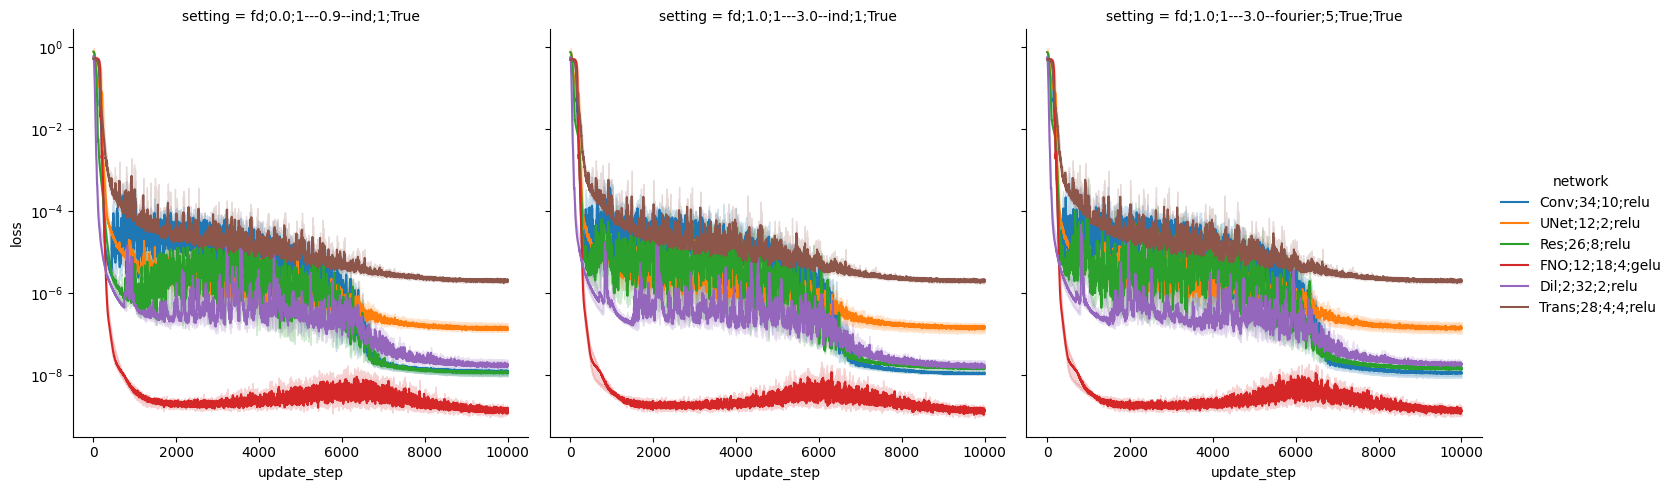

In [7]:
facet = sns.relplot(
    data=losses,
    x="update_step",
    y="loss",
    col="setting",
    kind="line",
    hue="network",
    estimator="median",
    errorbar=("pi", 50),
)

for ax in facet.axes.flat:
    ax.set_yscale("log")

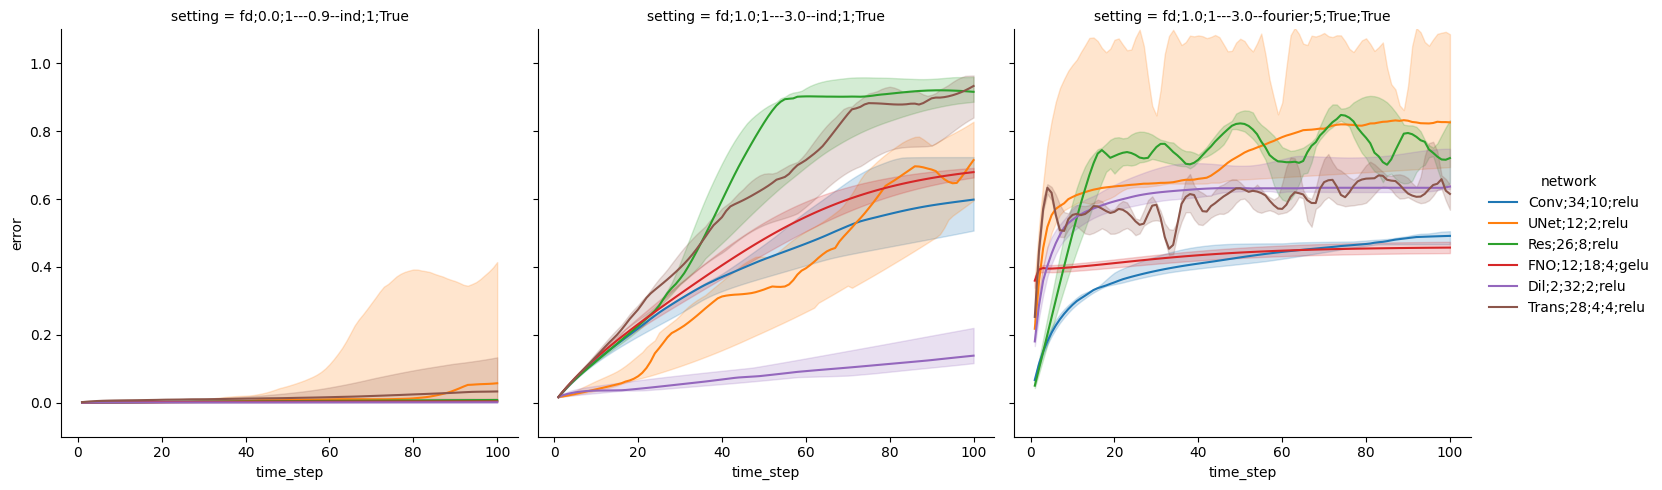

In [8]:
facet = sns.relplot(
    data=metrics.query("time_step <= 100"),
    x="time_step",
    y="error",
    hue="network",
    col="setting",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
)

for ax in facet.axes.flat:
    ax.set_ylim(-0.1, 1.1)

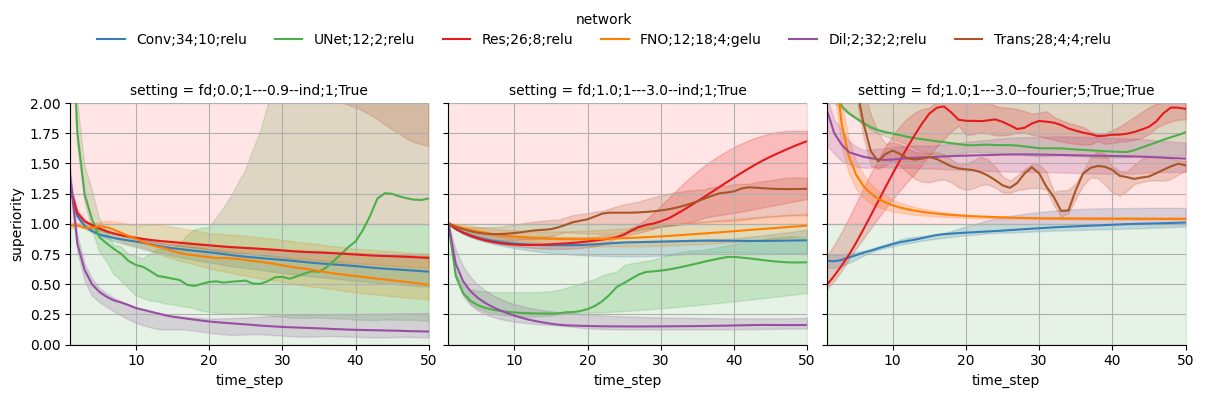

In [10]:
facet = sns.relplot(
    data=metrics.query("time_step <= 50"),
    x="time_step",
    y="superiority",
    hue="network",
    col="setting",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    palette=["#377eb8", "#4daf4a", "#e41a1c", "#ff7f00", "#984ea3", "#a65628"],
    height=4,
)

for ax in facet.axes.flat:
    ax.set_ylim(0.0, 2.0)
    ax.fill_between(
        ax.lines[0].get_xdata(),
        0.0,
        1.0,
        color="green",
        alpha=0.1,
    )
    ax.fill_between(
        ax.lines[0].get_xdata(),
        1.0,
        2.0,
        color="red",
        alpha=0.1,
    )
    ax.set_xlim(1, 50)
    ax.grid()

facet.figure.subplots_adjust(top=0.75)

sns.move_legend(facet, "upper center", ncol=6)

<>:53: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:57: SyntaxWarning: invalid escape sequence '\h'
<>:53: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:57: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_882618/2438050457.py:53: SyntaxWarning: invalid escape sequence '\h'
  facet.axes.flat[0].set_title("Autoregressive Generalization\nImplicit Reference ($\hat{\iota}_h, \gamma_1 = -3.0$)", fontsize=11)
/tmp/ipykernel_882618/2438050457.py:55: SyntaxWarning: invalid escape sequence '\h'
  facet.axes.flat[1].set_title("Autoregressive Generalization\nExplicit Reference ($\hat{e}_h, \gamma_1 = -0.9$)", fontsize=11)
/tmp/ipykernel_882618/2438050457.py:57: SyntaxWarning: invalid escape sequence '\h'
  facet.axes.flat[2].set_title("State-Space+Autoregr. Generalization\nImplicit Reference ($\hat{\iota}_h, \gamma_1 = -3.0$)", fontsize=11)


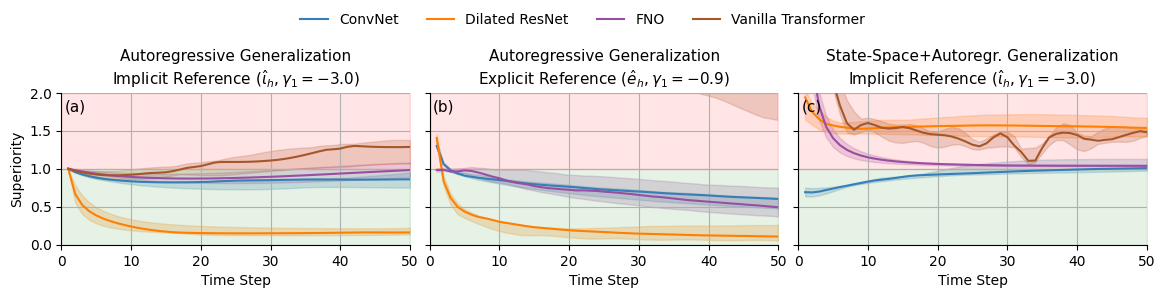

In [13]:
facet = sns.relplot(
    data=metrics.query("time_step <= 50"),
    x="time_step",
    y="superiority",
    hue="network",
    col="setting",
    col_order=["fd;1.0;1---3.0--ind;1;True", "fd;0.0;1---0.9--ind;1;True", "fd;1.0;1---3.0--fourier;5;True;True"],
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    hue_order=[
        "Conv;34;10;relu",
        # "UNet;12;2;relu",
        "Dil;2;32;2;relu",
        "FNO;12;18;4;gelu",
        "Trans;28;4;4;relu",
    ],
    palette=[
        "#377eb8",
        # "#e41a1c",
        "#ff7f00",
        "#984ea3",
        "#a65628",
    ],
    height=3.0,
    aspect=1.3,
)

for ax in facet.axes.flat:
    ax.set_ylim(0.0, 2.0)
    ax.fill_between(
        [0, 50],
        0.0,
        1.0,
        color="green",
        alpha=0.1,
    )
    ax.fill_between(
        [0, 50],
        1.0,
        2.0,
        color="red",
        alpha=0.1,
    )
    ax.set_xlim(0, 50)
    ax.grid()
    ax.set_xlabel("Time Step")

facet.axes.flat[0].set_ylabel("Superiority")
facet.axes.flat[0].set_yticks([0.0, 0.5, 1.0, 1.5, 2.0])

# facet.axes.flat[0].set_title("$\hat{\mathbf{r}}_h = \hat{\iota}_h$ (implicit ref.)\n$\gamma_1 = -3.0$")
facet.axes.flat[0].set_title("Autoregressive Generalization\nImplicit Reference ($\hat{\iota}_h, \gamma_1 = -3.0$)", fontsize=11)
# facet.axes.flat[1].set_title("$\hat{\mathbf{r}}_h = \hat{\mathbf{e}}_h$ (explicit ref.)\n$\gamma_1 = -0.9$")
facet.axes.flat[1].set_title("Autoregressive Generalization\nExplicit Reference ($\hat{e}_h, \gamma_1 = -0.9$)", fontsize=11)
# facet.axes.flat[2].set_title("$\hat{\mathbf{r}}_h = \hat{\iota}_h$ (implicit ref.)\n$\gamma_1 = -3.0$")
facet.axes.flat[2].set_title("State-Space+Autoregr. Generalization\nImplicit Reference ($\hat{\iota}_h, \gamma_1 = -3.0$)", fontsize=11)

# Add an "(a)" in the top left of the zeroth axis
facet.axes.flat[0].text(0.01, 0.88, "(a)", transform=facet.axes.flat[0].transAxes, fontsize=11)
facet.axes.flat[1].text(0.01, 0.88, "(b)", transform=facet.axes.flat[1].transAxes, fontsize=11)
facet.axes.flat[2].text(0.01, 0.88, "(c)", transform=facet.axes.flat[2].transAxes, fontsize=11)

facet.figure.subplots_adjust(top=0.7)

# Change legend entries to Just "Conv", "Dil", "FNO", "Trans"
sns.move_legend(facet, "upper center", ncol=6, title="", labels=["ConvNet", "Dilated ResNet", "FNO", "Vanilla Transformer"])

facet.figure.savefig("advection_nonlinear_emulator_experiment.pdf", bbox_inches="tight")